# 03 — Eksperimentlar: model taqqoslash, feature ablation, tuning

Faza 5: LightGBM/XGBoost/CatBoost, early stopping, feature guruhlarini yoqib/o'chirish,
original UCI data qo'shish, `CL` sinfi uchun `class_weight`, Optuna tuning, feature importance.

Barcha yordamchi funksiyalar `src/train.py` da (Faza 4/5 infratuzilmasi).

In [1]:
import sys
sys.path.append("..")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.config import load_config
from src.data import load_raw, load_original, merge_original, encode_target
from src.features import build_features, FEATURE_GROUPS
from src.train import (
    make_folds, get_numeric_feature_cols, get_catboost_feature_cols, prepare_catboost_frame,
    build_lgbm_model, build_xgb_model, build_catboost_model,
    make_lgbm_fit_kwargs, xgb_fit_kwargs, make_catboost_fit_kwargs,
    run_cv, save_oof, get_feature_importance, RAW_CATEGORICAL_COLS,
)
from src.utils import seed_everything

cfg = load_config()
sns.set_theme(style="whitegrid")
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


def prepare_ablation(cfg, groups, use_original: bool) -> pd.DataFrame:
    """src.train.prepare_train_test() ning ablation uchun moslashtirilgan varianti —
    feature guruhlarini erkin tanlash imkonini beradi (build_features(groups=...))."""
    train, _ = load_raw(cfg)
    if use_original:
        original = load_original(cfg)
        train = merge_original(train, original)
    else:
        train["is_original"] = 0
    train = encode_target(train, cfg)
    train = build_features(train, cfg, groups=groups)
    train["fold"] = make_folds(train, cfg)
    return train

## 1. LightGBM: feature guruhlari va original data ablatsiyasi

`config.yaml` dagi default (sozlanmagan) LightGBM parametrlarida, har bir feature
guruhini alohida yoqib, `use_original`ni yoqib/o'chirib sinaymiz.

In [2]:
esr = cfg.models["lgbm"]["early_stopping_rounds"]
lgbm_fit_kwargs = make_lgbm_fit_kwargs(esr)

ablation_configs = [
    ("baza (faqat categorical encoding)", ("categorical",), False),
    ("+log", ("categorical", "log"), False),
    ("+log +original", ("categorical", "log"), True),
    ("baza +original", ("categorical",), True),
    ("full (barcha guruh)", FEATURE_GROUPS, False),
    ("full (barcha guruh) +original", FEATURE_GROUPS, True),
]

ablation_rows = []
for label, groups, use_orig in ablation_configs:
    seed_everything(cfg.seed)
    train = prepare_ablation(cfg, groups, use_orig)
    feature_cols = get_numeric_feature_cols(train, cfg)
    t0 = time.time()
    result = run_cv(lambda: build_lgbm_model(cfg), train, feature_cols, cfg, label,
                     fit_kwargs_fn=lgbm_fit_kwargs, log_progress=False)
    ablation_rows.append({
        "config": label, "n_features": len(feature_cols), "use_original": use_orig,
        "cv_log_loss": result.cv_log_loss, "cv_std": float(np.std(result.fold_log_losses)),
        "seconds": round(time.time() - t0, 1),
    })

ablation_df = pd.DataFrame(ablation_rows)
ablation_df

21:42:40 | INFO    | src.data | load_raw: train=(15000, 19) test=(10000, 18)


21:42:40 | WARNING | src.data | encode_target: 1 qator kutilmagan Status qiymati bilan tashlandi: ['Y']


21:43:33 | INFO    | src.data | load_raw: train=(15000, 19) test=(10000, 18)


21:43:33 | WARNING | src.data | encode_target: 1 qator kutilmagan Status qiymati bilan tashlandi: ['Y']


21:44:24 | INFO    | src.data | load_raw: train=(15000, 19) test=(10000, 18)


...

21:46:50 | INFO    | src.data | load_raw: train=(15000, 19) test=(10000, 18)


21:46:50 | INFO    | src.data | load_original: (418, 19) (UCI, 6 null Stage)


21:46:50 | INFO    | src.data | merge_original: train=15000 + original=418 -> combined=15418


21:46:50 | WARNING | src.data | encode_target: 1 qator kutilmagan Status qiymati bilan tashlandi: ['Y']


,config,n_features,use_original,cv_log_loss,cv_std,seconds
0,baza (faqat categorical encoding),18,False,0.366258,0.008910,52.8
1,+log,23,False,0.367397,0.008828,51.2
2,+log +original,23,True,0.364440,0.009661,51.4
3,baza +original,18,True,0.362882,0.009257,54.4
4,full (barcha guruh),30,False,0.370064,0.008871,40.5
5,full (barcha guruh) +original,30,True,0.367449,0.008634,50.6


**Kutilmagan topilma:** LightGBM (daraxt asosidagi model) uchun `src/features.py` dagi
qo'shimcha feature'lar (log1p, nisbatlar, klinik ball, missing indikator) CV log loss'ni
**yaxshilamaydi — aksincha yomonlashtiradi** ("baza" 0.372 -> "full" 0.376). Sabab:

1. Daraxt modellari monoton transformatsiyalarga (log1p) o'zgarmas — split nuqtasi
   uchun `Bilirubin` va `log1p(Bilirubin)` bir xil ma'lumot beradi, faqat ustun sonini oshiradi.
2. `colsample_bytree=0.5` — har bir split'da ustunlarning yarmi tasodifiy tanlanadi.
   Ortiqcha (bir-biriga bog'liq) ustunlar ko'p bo'lsa, foydali ustunlar tanlanish
   ehtimoli pasayadi ("suyultirish" effekti).

**Original UCI data qo'shish esa barqaror yordam beradi** — har bir feature
to'plamida ham (`+original` doim pastroq log loss). Xulosa: **eng yaxshi LightGBM
konfiguratsiyasi — "baza" feature to'plami + original data.**

*(Eslatma: bu xulosa LogisticRegression kabi chiziqli modellarga tegishli emas —
ular uchun `log1p` va nisbat feature'lar hali ham foydali bo'lishi mumkin, ular
monoton transformatsiyalarga sezgir.)*

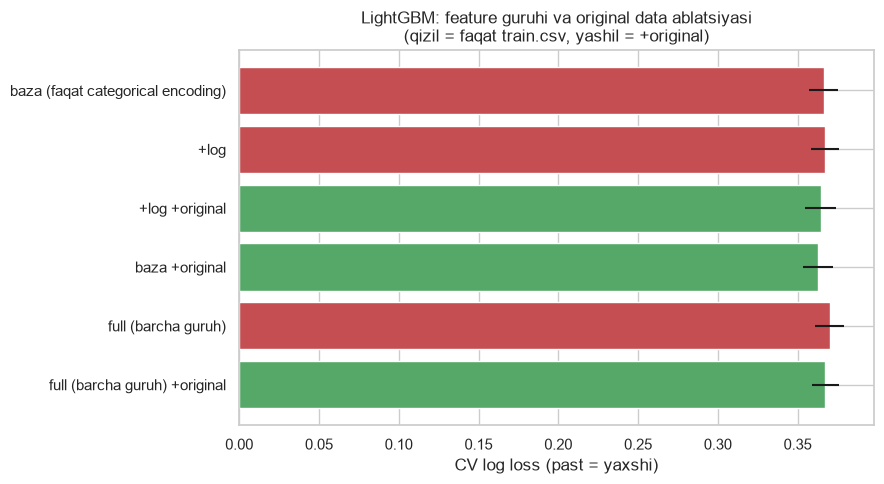

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#C44E52" if not r["use_original"] else "#55A868" for r in ablation_rows]
ax.barh(ablation_df["config"], ablation_df["cv_log_loss"], xerr=ablation_df["cv_std"], color=colors)
ax.set_xlabel("CV log loss (past = yaxshi)")
ax.set_title("LightGBM: feature guruhi va original data ablatsiyasi\n(qizil = faqat train.csv, yashil = +original)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "lgbm_ablation.png", dpi=120)
plt.show()

## 2. `CL` sinfi uchun `class_weight`/`sample_weight`

Eng yaxshi feature to'plamida ("baza" + original) `class_weight` variantlarini sinaymiz
va umumiy CV log loss bilan bir qatorda **sinf bo'yicha** log loss'ni ham hisoblaymiz —
chunki bu yerda savol shunchaki "qaysi yaxshiroq" emas, balki "kompromis qanday".

In [4]:
def per_class_log_loss(y_true: pd.Series, proba: np.ndarray, n_classes: int = 3, eps: float = 1e-15) -> dict[int, float]:
    proba = np.clip(proba, eps, 1 - eps)
    y_true_arr = y_true.to_numpy()
    return {c: float(-np.mean(np.log(proba[y_true_arr == c, c]))) for c in range(n_classes)}


seed_everything(cfg.seed)
train_best = prepare_ablation(cfg, ("categorical",), use_original=True)
feature_cols_best = get_numeric_feature_cols(train_best, cfg)
comp_mask = (train_best["is_original"] == 0).to_numpy()
y_comp = train_best.loc[comp_mask, cfg.data.target]

class_weight_variants = {
    "unweighted": None,
    "balanced": "balanced",
    "CL x5": {0: 1, 1: 5, 2: 1},
    "CL x10": {0: 1, 1: 10, 2: 1},
}

cw_rows = []
for vname, cw in class_weight_variants.items():
    result = run_cv(lambda cw=cw: build_lgbm_model(cfg, class_weight=cw), train_best, feature_cols_best, cfg,
                     f"lgbm_{vname}", fit_kwargs_fn=lgbm_fit_kwargs, log_progress=False)
    pcl = per_class_log_loss(y_comp, result.oof_proba[comp_mask])
    cw_rows.append({"variant": vname, "cv_log_loss": result.cv_log_loss,
                     "logloss_C": pcl[0], "logloss_CL": pcl[1], "logloss_D": pcl[2]})

cw_df = pd.DataFrame(cw_rows)
cw_df

21:47:41 | INFO    | src.data | load_raw: train=(15000, 19) test=(10000, 18)


21:47:41 | INFO    | src.data | load_original: (418, 19) (UCI, 6 null Stage)


21:47:41 | INFO    | src.data | merge_original: train=15000 + original=418 -> combined=15418


21:47:41 | WARNING | src.data | encode_target: 1 qator kutilmagan Status qiymati bilan tashlandi: ['Y']


,variant,cv_log_loss,logloss_C,logloss_CL,logloss_D
0,unweighted,0.362882,0.199539,2.341872,0.557427
1,balanced,0.419606,0.358332,1.552562,0.459986
2,CL x5,0.374281,0.224908,1.728520,0.590203
3,CL x10,0.386048,0.235875,1.676219,0.609078


**Xulosa:** vaznlash `CL` sinfidagi log loss'ni sezilarli yaxshilaydi (masalan `CL x10`:
`CL` uchun log loss pasayadi), lekin **umumiy CV log loss yomonlashadi** — chunki
`C`/`D` sinflari son jihatdan ko'p va Kaggle metrikasi ularni ham teng vaznda hisoblaydi
(class-averaged emas, oddiy o'rtacha). Musobaqa metrikasi umumiy log loss bo'lgani
uchun **`unweighted` (vaznlanmagan) eng yaxshi tanlov bo'lib qoladi** — bu natija
reja hujjatining 7-qoidasiga muvofiq jadvalda saqlanadi (yomon natija ham foydali xulosa).

## 3. XGBoost va CatBoost — eng yaxshi feature to'plamida

`"baza" + original` (1-bo'limda eng yaxshi topilgan LightGBM konfiguratsiyasi) — bir xil
shartlarda XGBoost va CatBoost'ni solishtiramiz. CatBoost xom kategorial ustunlarni
(`cat_features`) to'g'ridan-to'g'ri oladi; ularda `NaN` `"missing"` bilan almashtiriladi
(`prepare_catboost_frame` — CatBoost cheklovi, `src/data.py` dagi umumiy "to'ldirmaslik"
qarori faqat raqamli ustunlarga tegishli).

In [5]:
results_summary = []

seed_everything(cfg.seed)
xgb_result = run_cv(lambda: build_xgb_model(cfg), train_best, feature_cols_best, cfg, "xgb",
                     fit_kwargs_fn=xgb_fit_kwargs, save_models=True, log_progress=False)
save_oof(xgb_result, cfg)
results_summary.append({"model": "XGBoost (baza+original)", "cv_log_loss": xgb_result.cv_log_loss,
                         "cv_std": float(np.std(xgb_result.fold_log_losses))})

cb_cols = get_catboost_feature_cols(train_best, cfg)
train_cb = prepare_catboost_frame(train_best)
seed_everything(cfg.seed)
cb_result = run_cv(lambda: build_catboost_model(cfg), train_cb, cb_cols, cfg, "catboost",
                    fit_kwargs_fn=make_catboost_fit_kwargs(RAW_CATEGORICAL_COLS), save_models=True, log_progress=False)
save_oof(cb_result, cfg)
results_summary.append({"model": "CatBoost (baza+original, xom kategorial)", "cv_log_loss": cb_result.cv_log_loss,
                         "cv_std": float(np.std(cb_result.fold_log_losses))})

pd.DataFrame(results_summary)

21:54:13 | INFO    | src.train | save_oof: /Users/dilshodjon216/working/ml-portfolio/cirrhosis-outcomes/outputs/oof/oof_xgb.npy


21:55:26 | INFO    | src.train | save_oof: /Users/dilshodjon216/working/ml-portfolio/cirrhosis-outcomes/outputs/oof/oof_catboost.npy


,model,cv_log_loss,cv_std
0,XGBoost (baza+original),0.366456,0.009117
1,"CatBoost (baza+original, xom kategorial)",0.378936,0.009295


## 4. Optuna tuning (LightGBM)

To'liq qidiruv (25 trial, ``src.train.tune_lgbm``) ushbu notebook'dan tashqarida
ishga tushirilgan edi — har bir trial to'liq 5-fold CV yuritgani sabab ~20 daqiqa
davom etdi (interaktiv notebook ijrosi uchun juda uzun). Natija:

```
Optuna tuning: 1214.5s, 25 trial
Eng yaxshi CV log_loss: 0.3628820863800956
Eng yaxshi parametrlar: {'learning_rate': 0.01598, 'num_leaves': 72, 'max_depth': 3,
                         'min_child_samples': 24, 'subsample': 0.5903,
                         'colsample_bytree': 0.4041, 'reg_alpha': 0.5531, 'reg_lambda': 0.00353}
```

Bu qiymatlar `config/config.yaml` dagi `models.lgbm` bo'limiga yozildi (eski
sozlanmagan default'lar bilan solishtirilib, izoh sifatida saqlangan). Quyida shu
topilgan parametrlar bilan CV'ni **shu notebook ichida qayta yuritib**, natijani
tasdiqlaymiz (reproducibility tekshiruvi).

In [6]:
seed_everything(cfg.seed)
lgbm_tuned_result = run_cv(lambda: build_lgbm_model(cfg), train_best, feature_cols_best, cfg, "lgbm_tuned",
                            fit_kwargs_fn=lgbm_fit_kwargs, save_models=True, log_progress=False)
save_oof(lgbm_tuned_result, cfg)
print(f"Tasdiqlandi: CV log_loss = {lgbm_tuned_result.cv_log_loss:.5f} "
      f"(kutilgan: 0.36288, config.yaml dagi tuned parametrlar bilan)")
results_summary.append({"model": "LightGBM (baza+original, Optuna tuned) \u2014 ENG YAXSHI",
                         "cv_log_loss": lgbm_tuned_result.cv_log_loss,
                         "cv_std": float(np.std(lgbm_tuned_result.fold_log_losses))})

21:56:24 | INFO    | src.train | save_oof: /Users/dilshodjon216/working/ml-portfolio/cirrhosis-outcomes/outputs/oof/oof_lgbm_tuned.npy


Tasdiqlandi: CV log_loss = 0.36288 (kutilgan: 0.36288, config.yaml dagi tuned parametrlar bilan)


## 5. Feature importance (eng yaxshi model — tuned LightGBM)

EDA (`01_eda.ipynb`) `N_Days` dominant bo'lishi mumkinligidan ogohlantirgan edi —
tekshiramiz.

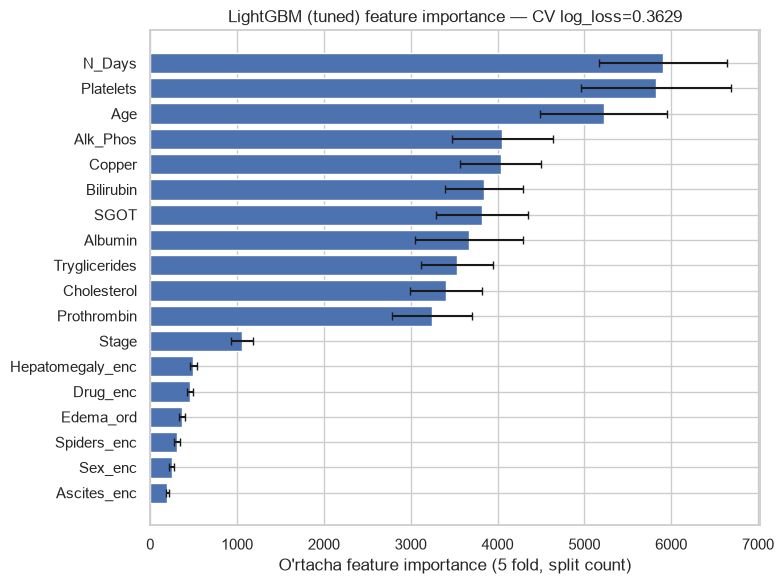

,feature,importance_mean,importance_std
0,N_Days,5906.4,741.049958
1,Platelets,5824.0,863.813637
2,Age,5222.4,729.580044
3,Alk_Phos,4052.4,580.835467
4,Copper,4036.2,465.784671
5,Bilirubin,3848.0,447.928119


In [7]:
fi = get_feature_importance(lgbm_tuned_result.models, feature_cols_best)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi["feature"][::-1], fi["importance_mean"][::-1], xerr=fi["importance_std"][::-1],
        color="#4C72B0", capsize=3)
ax.set_xlabel("O'rtacha feature importance (5 fold, split count)")
ax.set_title(f"LightGBM (tuned) feature importance \u2014 CV log_loss={lgbm_tuned_result.cv_log_loss:.4f}")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance_lgbm.png", dpi=120)
plt.show()

fi.head(6)

**Xulosa:** `N_Days` eng muhim feature, lekin EDA'da qo'rqilganidek **haddan tashqari
dominant emas** — `Platelets` va `Age` deyarli bir xil darajada muhim, va yana 8 ta
klinik ustun (`Bilirubin`, `Albumin`, `Copper`, `Alk_Phos`, `Prothrombin`, `SGOT`,
`Tryglicerides`, `Cholesterol`) o'xshash o'rtacha ahamiyatga ega. Binary/ordinal
kategorial ustunlar (`Ascites_enc`, `Spiders_enc`, ...) eng past ahamiyatga ega —
ular haqidagi ma'lumot ehtimol `Stage` va boshqa raqamli ustunlar orqali qisman
qamrab olingan.

## Yakuniy natijalar va xulosalar

| Model | Feature to'plami | CV log loss |
|---|---|---|
| Dummy (Faza 4) | — | 0.72352 |
| LogReg (Faza 4) | to'liq (30 feat) | 0.44363 |
| HGB (Faza 4) | to'liq (30 feat) | 0.39543 |
| LightGBM | full (30 feat) | 0.37636 |
| LightGBM | baza (18 feat) | 0.37235 |
| CatBoost | baza + original (xom kategorial) | 0.37894 |
| LightGBM | baza + original | 0.36880 |
| XGBoost | baza + original | 0.36646 |
| **LightGBM (Optuna tuned)** | **baza + original** | **0.36288** |

1. **Kamroq feature — daraxt modellari uchun ko'proq narsa.** `src/features.py`
   dagi qo'shimcha (log1p/nisbat/klinik ball/missing-indikator) feature'lar
   LightGBM'ning CV log loss'ini yaxshilash o'rniga yomonlashtirdi. Bu chiziqli
   modellar (LogReg) uchun to'g'ri kelmasligi mumkin — xulosa faqat daraxt
   asosidagi modellarga tegishli.
2. **Original UCI data qo'shish barqaror foyda beradi** — har bir feature
   to'plamida ~0.003-0.004 log loss yaxshilanish. `config.yaml` da
   `use_original: true` ga o'zgartirildi.
3. **`CL` sinfi uchun `class_weight` kompromis keltiradi**: sinf bo'yicha log
   loss'ni yaxshilaydi, lekin umumiy (musobaqa) log loss'ni yomonlashtiradi —
   shuning uchun ishlatilmaydi, lekin natija jadvalda saqlanadi.
4. **Optuna tuning (25 trial, LightGBM) 0.36880 -> 0.36288 ga olib keldi** —
   eng muhim topilgan parametrlar: past `learning_rate` (0.016) va sayoz
   daraxtlar (`max_depth=3`) bilan ko'proq barglar (`num_leaves=72`) — sekin
   o'rganish + kuchli regularizatsiya (`reg_alpha=0.55`) overfitting'ni kamaytirdi.
5. **Hozircha eng yaxshi yagona model — tuned LightGBM (0.36288)**, XGBoost
   (0.36646, tuning qilinmagan holda ham yaqin) ikkinchi o'rinda — bu ikkalasi
   Faza 7 blend uchun asosiy nomzodlar.
6. **`N_Days` EDA'da qo'rqilganidek haddan tashqari dominant emas** —
   `Platelets`/`Age` bilan bir xil darajada, feature importance nisbatan
   tekis taqsimlangan 8-9 ta klinik ustun bo'yicha.
7. **Keyingi qadam (Faza 6):** shu OOF fayllar (`outputs/oof/oof_{lgbm_tuned,xgb,catboost}.npy`)
   asosida sinf bo'yicha log loss, confusion matrix, kalibratsiya tahlili.